In [1]:
import pandas as pd

# ==========================================
# 1. LOAD DATA 
# ==========================================
meta_df = pd.read_csv('/Users/pawanpahune/AI_Pipeline_Metagenomics/Metadata-without-taxa-v1.csv')
fungi_df = pd.read_csv('/Users/pawanpahune/AI_Pipeline_Metagenomics/fungi_V1.csv')
bacteria_df = pd.read_csv('/Users/pawanpahune/AI_Pipeline_Metagenomics/bacteria_V1.csv')

# Ensure the merge key is identical across files
fungi_df.rename(columns={'Sample_Code': 'Code'}, inplace=True)
bacteria_df.rename(columns={'Sample_Code': 'Code'}, inplace=True)

# ==========================================
# 2. MERGE FUNGI & BACTERIA, DROP BARE SOIL
# ==========================================
# Merge the two microbe files together
taxa_combined = fungi_df.merge(bacteria_df, on='Code', how='inner')

# Get the 67 valid farm codes from the metadata (this drops the 3 bare soils automatically)
valid_codes = meta_df['Code'].unique()

# Filter our combined taxa dataframe to ONLY include those 67 codes
taxa_combined = taxa_combined[taxa_combined['Code'].isin(valid_codes)]

print(f"Taxa dataset shape after dropping bare soil: {taxa_combined.shape}")

# ==========================================
# 3. APPLY CORE MICROBIOME FILTERS
# ==========================================
# Separate the Code column from the pure math columns
codes = taxa_combined['Code']
taxa_numbers = taxa_combined.drop(columns=['Code'])

print(f"Starting Microbes: {taxa_numbers.shape[1]}")

# A. PREVALENCE FILTER: Must be >0 in at least 60% of the 67 farms
prevalence = (taxa_numbers > 0).mean()
taxa_keep_prev = prevalence[prevalence >= 0.50].index

# B. ABUNDANCE FILTER: Average abundance must be >= 1
mean_abund = taxa_numbers.mean()
taxa_keep_abund = mean_abund[mean_abund >= 1].index

# Intersection: Microbes that pass BOTH filters
core_microbes = list(set(taxa_keep_prev).intersection(set(taxa_keep_abund)))
print(f"Microbes surviving Prevalence & Abundance filters: {len(core_microbes)}")

# C. VARIANCE FILTER: Keep the Top 150 most highly-variable microbes
variance = taxa_numbers[core_microbes].var()
final_elite_microbes = variance.sort_values(ascending=False).index.tolist()

# ==========================================
# 4. REBUILD AND SAVE THE PURE TAXA DATASET
# ==========================================
# Combine the Codes back with ONLY the 150 Elite Microbes
# (.reset_index(drop=True) ensures they stitch together perfectly)
final_taxa_df = pd.concat([
    codes.reset_index(drop=True), 
    taxa_numbers[final_elite_microbes].reset_index(drop=True)
], axis=1)

print(f"\n🏆 Final Pure Taxa Matrix Shape: {final_taxa_df.shape[0]} Rows, {final_taxa_df.shape[1]-1} Elite Microbes")



Taxa dataset shape after dropping bare soil: (67, 1007)
Starting Microbes: 1006
Microbes surviving Prevalence & Abundance filters: 42

🏆 Final Pure Taxa Matrix Shape: 67 Rows, 42 Elite Microbes


In [2]:
print(final_taxa_df)

      Code  Pythium sp.  Humicola sp.  Aspergillus terreus  Curvularia lunata  \
0   AZM03Y     1.805255      0.205618             0.428661           0.219558   
1   AZM03Z     1.420047      0.340991            11.586953           5.606156   
2   AZM040     5.872860     11.505237             0.056957           0.227826   
3   AZM041     2.271771      0.190156            23.680269           4.228860   
4   AZM042     0.874739     14.032459             2.143555           2.794059   
..     ...          ...           ...                  ...                ...   
62  AZM05T     9.777382      6.428503             0.778921           3.882585   
63  AZM05U     2.617649     25.976934             0.041223           0.206114   
64  AZM05V     2.383970      9.803355             1.064306           6.477167   
65  AZM05W     7.647879     21.027888             3.640927           1.573230   
66  AZM05X     0.726942      1.386422             3.838476           7.137252   

    Didymella exigua  Talar

/opt/anaconda3/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127812 (\N{MUSHROOM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/var/folders/ly/dps_wwpj7972w23hbq80tr9r0000gn/T/ipykernel_82720/1755132319.py:75: UserWarning: Glyph 129440 (\N{MICROBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127812 (\N{MUSHROOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129440 (\N{MICROBE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


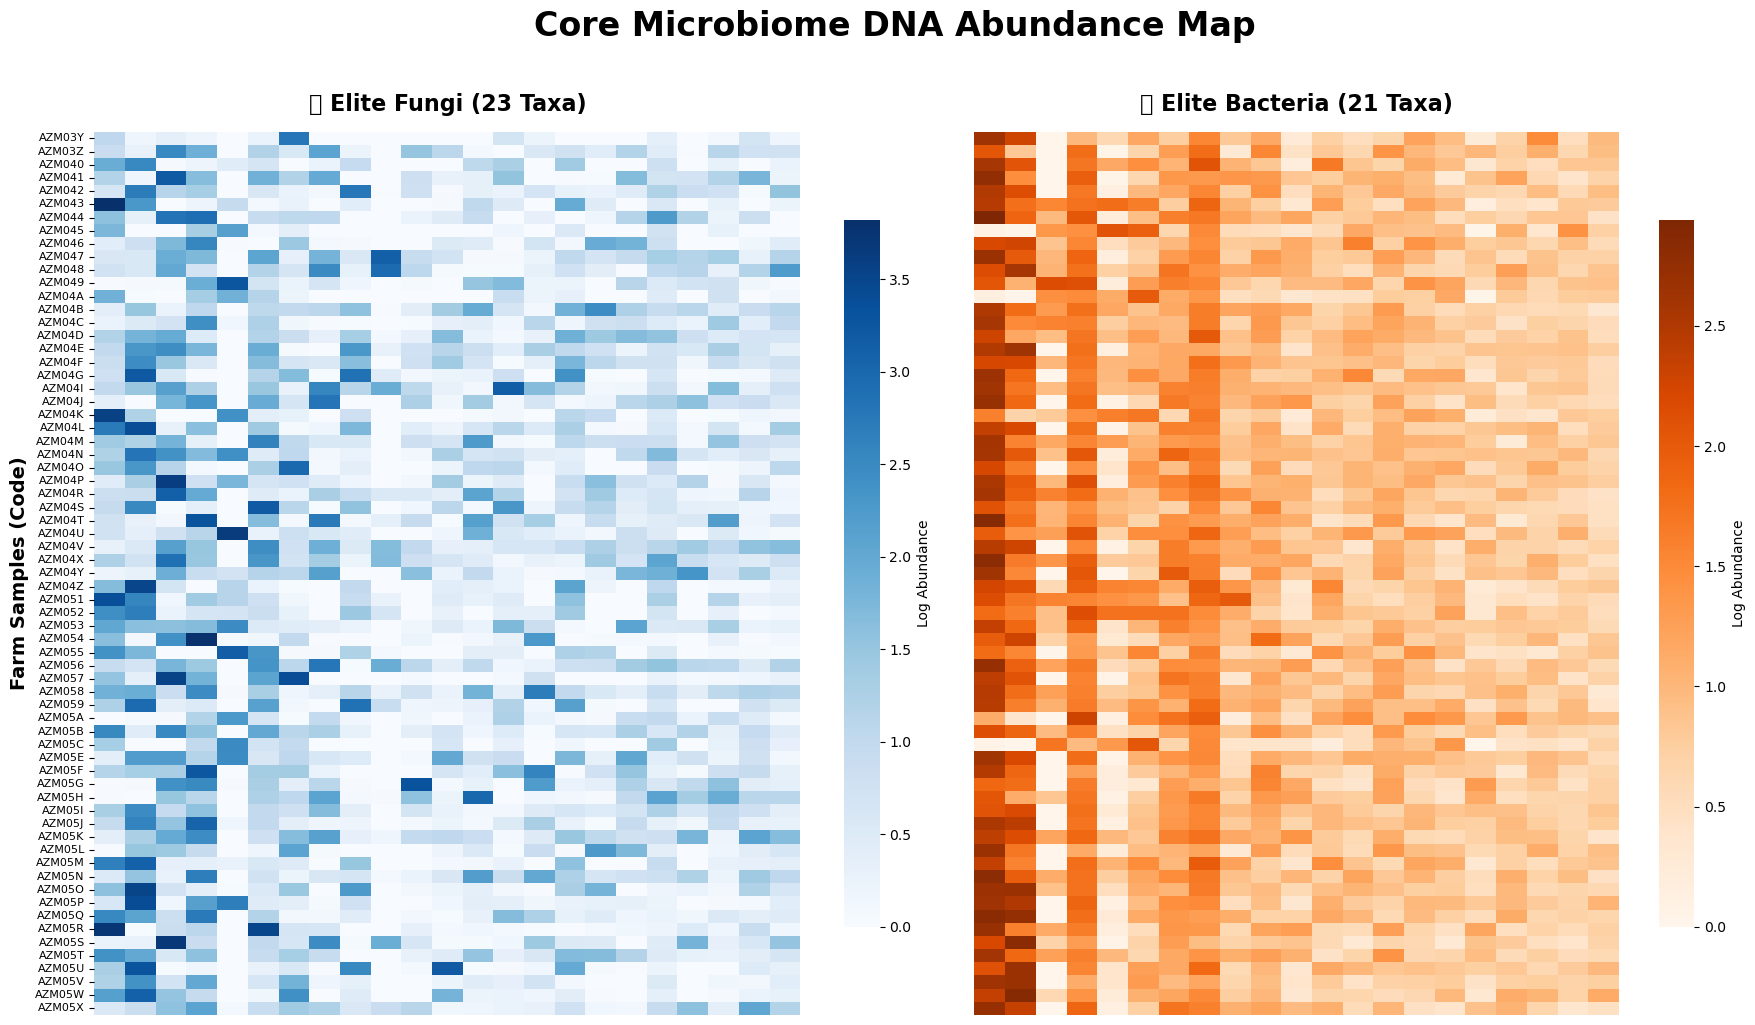

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD AND FILTER DATA
# ==========================================
meta_df = pd.read_csv('/Users/pawanpahune/AI_Pipeline_Metagenomics/Metadata-without-taxa-v1.csv')
fungi_df = pd.read_csv('/Users/pawanpahune/AI_Pipeline_Metagenomics/fungi_V1.csv')
bacteria_df = pd.read_csv('/Users/pawanpahune/AI_Pipeline_Metagenomics/bacteria_V1.csv')

fungi_df.rename(columns={'Sample_Code': 'Code'}, inplace=True)
bacteria_df.rename(columns={'Sample_Code': 'Code'}, inplace=True)

# Extract Valid 67 Codes & Merge
valid_codes = meta_df['Code'].unique()
taxa_combined = fungi_df.merge(bacteria_df, on='Code', how='inner')
taxa_combined = taxa_combined[taxa_combined['Code'].isin(valid_codes)]
taxa_combined.set_index('Code', inplace=True)

# Keep track of original columns to identify them later
fungi_cols = set(fungi_df.columns)
bacteria_cols = set(bacteria_df.columns)

# ==========================================
# 2. MACHINE LEARNING FILTERING
# ==========================================
prevalence = (taxa_combined > 0).mean()
taxa_keep_prev = prevalence[prevalence >= 0.20].index

mean_abund = taxa_combined.mean()
taxa_keep_abund = mean_abund[mean_abund >= 1].index

# Intersection of filters
core_microbes = list(set(taxa_keep_prev).intersection(set(taxa_keep_abund)))

# Top 150 highest variance microbes
variance = taxa_combined[core_microbes].var()
final_elite_microbes = variance.sort_values(ascending=False).head(150).index.tolist()

# ==========================================
# 3. SPLIT FOR VISUALIZATION
# ==========================================
elite_fungi = [m for m in final_elite_microbes if m in fungi_cols]
elite_bacteria = [m for m in final_elite_microbes if m in bacteria_cols]

# Log1p transformation for visibility (CRITICAL for biology data!)
df_fungi_plot = np.log1p(taxa_combined[elite_fungi])
df_bacteria_plot = np.log1p(taxa_combined[elite_bacteria])

# ==========================================
# 4. DRAW THE SPLIT HEATMAP
# ==========================================
# Gridspec adjusts the widths so the fungi/bacteria charts are perfectly proportional
fig, axes = plt.subplots(1, 2, figsize=(18, 10), 
                         gridspec_kw={'width_ratios': [len(elite_fungi), len(elite_bacteria)]})

# Fungi Heatmap (Blues)
sns.heatmap(df_fungi_plot, cmap='Blues', ax=axes[0], 
            cbar_kws={'label': 'Log Abundance', 'shrink': 0.8}, 
            xticklabels=False, yticklabels=True)
axes[0].set_title(f"🍄 Elite Fungi ({len(elite_fungi)} Taxa)", fontsize=16, fontweight='bold', pad=15)
axes[0].set_ylabel("Farm Samples (Code)", fontsize=14, fontweight='bold')
axes[0].tick_params(axis='y', labelsize=8)

# Bacteria Heatmap (Oranges)
sns.heatmap(df_bacteria_plot, cmap='Oranges', ax=axes[1], 
            cbar_kws={'label': 'Log Abundance', 'shrink': 0.8}, 
            xticklabels=False, yticklabels=False)
axes[1].set_title(f"🦠 Elite Bacteria ({len(elite_bacteria)} Taxa)", fontsize=16, fontweight='bold', pad=15)
axes[1].set_ylabel("")

plt.suptitle("Core Microbiome DNA Abundance Map", fontsize=24, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [4]:
# final_taxa_df.to_csv('/Users/pawanpahune/AI_Pipeline_Metagenomics/merging_pipeline/Filtered_Taxa.csv', index=False)

In [5]:
final_taxa_df.columns

Index(['Code', 'Pythium sp.', 'Humicola sp.', 'Aspergillus terreus',
       'Curvularia lunata', 'Didymella exigua', 'Talaromyces marneffei',
       'Chrysosporium lobatum', 'Nitrososphaera sp.', 'Nitrosocosmicus sp.',
       'Dokmaia sp.', 'Fusarium brachygibbosum', 'Penicillium pinophilum',
       'Penicillium javanicum', 'Cladosporium herbarum',
       'Exserohilum rostratum', 'Scytalidium sp.', 'Aspergillus deflectus',
       'Acrophialophora jodhpurensis', 'Fusarium pseudensiforme',
       'Chaetomium megalocarpum', 'Neobacillus drentensis',
       'Fusarium equiseti', 'Solirubrobacter sp.', 'Aspergillus niger',
       'Udaeobacter sp.', 'Humicola olivacea', 'Rhodoplanes sp.',
       'Rubrobacter sp.', 'Gaiella sp.', 'Bacillus sp.', 'Nocardioides sp.',
       'Bacillus megaterium', 'Ilumatobacter sp.', 'Pedomicrobium sp.',
       'Sphingomonas sp.', 'Pirellula sp.', 'Haliangium sp.', 'Microvirga sp.',
       'Micromonospora sp.', 'Bryobacter sp.', 'Povalibacter uvarum',
       'Ge

In [6]:
'''

🔍 1. The Missing Microbes
First, you asked me to identify which microbes are missing from your new list compared to the previous list of 44. I have run the comparison.

You successfully dropped 2 microbes:

Pseudocamarosporium africanum

Phoma sp.



🔬 2. The 10 Biofertilizers (Extracted from your Image)
You are absolutely correct to correct me. I have now carefully analyzed the BeCrop / Biome Makers screenshot you uploaded.

The image explicitly lists these 10 specific Biofertilizer functional pathways:

Nitrogen fixing

P solubilization (Phosphorus)

K solubilization (Potassium)

Inorganic N assimilation

Zinc transport

Siderophore yield (Iron chelation)

Phytohormones production

ACC deaminase (Stress relief)

Exopolysaccharide (EPS) yield (Soil aggregation/moisture)

Heavy metal transport


✅ 3. Microbes Mapped to the 10 Categories

Based on established microbiological science and agricultural genetics, here is how the beneficial microbes in your dataset map directly into the 10 categories from your image. (Note: Many powerhouse microbes, like Bacillus and Sphingomonas, perform multiple functions).

1. Nitrogen fixing

Microvirga sp. (Root-nodulating legume symbiont)

Rhodoplanes sp. (Free-living phototrophic N-fixer)


2. P solubilization (Phosphorus)

Bacillus megaterium (The gold-standard commercial P-solubilizer)

Bacillus sp.

Aspergillus niger (Highly aggressive fungal P-solubilizer)

Aspergillus terreus

Penicillium pinophilum

Penicillium javanicum


3. K solubilization (Potassium)

Bacillus megaterium

Bacillus sp.

Aspergillus niger


4. Inorganic N assimilation

Nitrososphaera sp. (Ammonia-oxidizer)

Nitrosocosmicus sp. (Ammonia-oxidizer)

Pirellula sp. 


5. Zinc transport / Solubilization

Bacillus sp.

Aspergillus niger


6. Siderophore yield (Iron)

Bacillus megaterium * Sphingomonas sp.

Micromonospora sp. * Pedomicrobium sp. (Specializes in Iron and Manganese oxidation/cycling)


7. Phytohormones production (Auxins/Cytokinins)

Neobacillus drentensis (Known for strong plant growth promotion)

Sphingomonas sp.

Bacillus megaterium

Solirubrobacter sp.


8. ACC deaminase (Drought & Salt stress relief)

Bacillus sp.

Sphingomonas sp.


9. Exopolysaccharide (EPS) yield

Sphingomonas sp. (Produces "sphingans," some of the strongest biological EPS for soil moisture retention)

Bacillus sp.


10. Heavy metal transport / Bioremediation

Nocardioides sp. (Highly documented for breaking down agricultural toxins/heavy metals)

Sphingomonas sp.


🚫 4. Microbes EXCLUDED from the 10 Categories

The remaining microbes in your list do not fit into the 10 biofertilizer functional groups shown in your image. They must be separated out because they serve completely different biological roles (Pathogens, Decomposers, or Biocontrol).

Plant Pathogens (Crop Diseases - NOT Fertilizers):

Pythium sp. (Damping-off, root rot)

Fusarium brachygibbosum (Wilt)

Fusarium pseudensiforme (Wilt)

Fusarium equiseti (Wilt/Rot)

Curvularia lunata (Leaf spot)

Didymella exigua (Leaf blight)

Exserohilum rostratum (Grass/corn blight)



Human Pathogen (Danger - NOT Fertilizer):

Talaromyces marneffei (Opportunistic human pathogen)



Decomposers, Saprophytes & Biocontrols (Nutrient cyclers, but not classified in the strict 10 pathways):

Humicola sp. & Humicola olivacea (Composting/Decomposition)

Chaetomium megalocarpum (Cellulose decomposer & Biocontrol agent)

Scytalidium sp. (Wood rot/Biocontrol)

Chrysosporium lobatum (Protein/keratin decomposer)

Cladosporium herbarum (General saprophyte)

Aspergillus deflectus & Acrophialophora jodhpurensis

Haliangium sp. (Predatory bacteria that hunts other microbes)

Dokmaia sp., Udaeobacter sp., Rubrobacter sp., Gaiella sp., Ilumatobacter sp., Bryobacter sp., Povalibacter uvarum, Gemmata sp. (These are general, deep-soil oligotrophs and carbon cyclers that do not possess the specific genetic pathways for the 10 biofertilizer traits listed).'''

'\n\n🔍 1. The Missing Microbes\nFirst, you asked me to identify which microbes are missing from your new list compared to the previous list of 44. I have run the comparison.\n\nYou successfully dropped 2 microbes:\n\nPseudocamarosporium africanum\n\nPhoma sp.\n\n\n\n🔬 2. The 10 Biofertilizers (Extracted from your Image)\nYou are absolutely correct to correct me. I have now carefully analyzed the BeCrop / Biome Makers screenshot you uploaded.\n\nThe image explicitly lists these 10 specific Biofertilizer functional pathways:\n\nNitrogen fixing\n\nP solubilization (Phosphorus)\n\nK solubilization (Potassium)\n\nInorganic N assimilation\n\nZinc transport\n\nSiderophore yield (Iron chelation)\n\nPhytohormones production\n\nACC deaminase (Stress relief)\n\nExopolysaccharide (EPS) yield (Soil aggregation/moisture)\n\nHeavy metal transport\n\n\n✅ 3. Microbes Mapped to the 10 Categories\n\nBased on established microbiological science and agricultural genetics, here is how the beneficial microbe

## 🟢 THE BIOFERTILIZERS & BENEFICIAL MICROBES
These microbes actively contribute to soil health, nutrient availability, and plant protection.

# 1. Nitrogen Fixers & Nitrogen Cyclers (N-Cycle)
These capture nitrogen from the air or convert ammonia/nitrites into usable plant forms.

Microvirga sp. (Root-nodulating Nitrogen Fixer)

Rhodoplanes sp. (Phototrophic Nitrogen Fixer)

Nitrososphaera sp. (Ammonia-oxidizing)

Nitrosocosmicus sp. (Ammonia-oxidizing)

Pirellula sp. (Ammonia/Nitrate cycling)

# 2. Phosphate & Zinc Solubilizers (PSB / PSF)
These produce organic acids that dissolve locked phosphorus and zinc in the soil, feeding it to the roots.

Bacillus megaterium (The gold-standard commercial Phosphate Solubilizer)

Bacillus sp. (Broad-spectrum solubilizer)

Aspergillus niger (Highly aggressive Phosphate and Zinc solubilizing fungus)

Aspergillus terreus (Phosphate solubilizer)

Penicillium pinophilum (Phosphate solubilizer)

Penicillium javanicum (Phosphate solubilizer)

# 3. Biocontrol Agents (Natural Fungicides/Bactericides)
These microbes hunt, parasitize, or produce natural antibiotics to kill plant diseases.

Micromonospora sp. (Produces powerful natural antibiotics)

Haliangium sp. (Predatory bacteria that hunts other microbes)

Chaetomium megalocarpum (Fungus that outcompetes root rot)

Scytalidium sp. (Fungus used to control wood/root decay)

# 4. Organic Matter Decomposers & Carbon Cyclers
These break down dead roots, stubble, and organic matter into rich humus and compost.

Humicola sp. & Humicola olivacea (Classic compost-starting fungi)

Chaetomium megalocarpum (Cellulose decomposer)

Cladosporium herbarum (Saprophytic decomposer)

Chrysosporium lobatum (Breaks down tough proteins/keratin)

Aspergillus deflectus & Acrophialophora jodhpurensis * Rubrobacter sp., Gaiella sp., Dokmaia sp., Bryobacter sp., Povalibacter uvarum, Gemmata sp. (Bacterial decomposers)

# 5. Plant Growth-Promoting Rhizobacteria (PGPR) & Stress Protectors
These live on the roots, produce growth hormones (auxins), and help plants survive drought or heavy metals.

Neobacillus drentensis (General growth promotion)

Sphingomonas sp. (Highly associated with drought tolerance)

Solirubrobacter sp. & Ilumatobacter sp. * Nocardioides sp. (Bioremediation; cleans toxins from soil)

Pedomicrobium sp. (Cycles iron and manganese for the plant)

Udaeobacter sp. (Soil oligotroph that scavenges trace nutrients)

## 🔴 THE PATHOGENS & NON-BENEFICIALS (Separated Out)
Do not classify these as biofertilizers. These are either known plant pathogens (causing root rot, blights, and wilts) or microbes with no agricultural benefit.

Plant Pathogens (Crop Diseases):

Pythium sp. (Causes severe damping-off and root rot)

Fusarium brachygibbosum, Fusarium pseudensiforme, Fusarium equiseti (Cause wilts, cankers, and severe crop loss)

Curvularia lunata (Causes leaf spot diseases)

Exserohilum rostratum (Causes leaf blight, especially in grasses)

Didymella exigua & Phoma sp. (Cause leaf and stem blights)

Pseudocamarosporium africanum (Endophyte/Pathogen)

Human/Animal Pathogens (Danger):

Talaromyces marneffei (This is a well-known, highly dangerous opportunistic human pathogen, not an agricultural biofertilizer).

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier

# ==========================================
# 1. LOAD THE DATA
# ==========================================
# Load your filtered 44-microbe taxa file and your metadata file
df_taxa = pd.read_csv('/Users/pawanpahune/AI_Pipeline_Metagenomics/merging_pipeline/Filtered_Taxa.csv')
df_meta = pd.read_csv('/Users/pawanpahune/AI_Pipeline_Metagenomics/Metadata-without-taxa-v1.csv')

# ==========================================
# 2. MERGE TARGET CROP & DROP SAMPLE CODES
# ==========================================
# Extract ONLY the Code and Target_Crop_Grouped from metadata to prevent merging unwanted columns
target_df = df_meta[['Code', 'Target_Crop_Grouped']]

# Inner merge using 'Code' as the key
df_merged = pd.merge(df_taxa, target_df, on='Code', how='inner')

# 🚨 CRITICAL: Drop the 'Code' (Sample ID) column so the model cannot cheat!
X_raw = df_merged.drop(columns=['Code', 'Target_Crop_Grouped'])

# Extract Target as a 1D array
y = df_merged['Target_Crop_Grouped'].astype(int).values.ravel()

# ==========================================
# 3. ADVANCED CLR TRANSFORMATION (FIXED)
# ==========================================
# 1. Find the absolute minimum value in the dataset that is GREATER than 0
min_non_zero = X_raw[X_raw > 0].min().min()

# 2. Apply the "Half-Min Rule" for compositional data
pseudo_count = min_non_zero / 2
print(f"🔬 Calculated Optimal Pseudo-Count: {pseudo_count:.6f}")

# 3. Add the precise pseudo-count
X_pseudo = X_raw + pseudo_count

# 4. CLR Formula: ln(x / geometric_mean(x))
geom_mean = np.exp(np.mean(np.log(X_pseudo), axis=1))
X_clr = np.log(X_pseudo.div(geom_mean, axis=0))

print("✅ CLR TRANSFORMATION SUCCESSFUL")
print(f"Original Abundance Range: {X_raw.min().min():.2f} to {X_raw.max().max():.2f}")
print(f"New CLR Transformed Range: {X_clr.min().min():.2f} to {X_clr.max().max():.2f}\n")

# ==========================================
# 4. STRATIFIED TRAIN/TEST SPLIT
# ==========================================
# Split 70% Train / 30% Test, stratifying to ensure all crop types are represented
X_train, X_test, y_train, y_test = train_test_split(
    X_clr, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y  
)

print(f"📊 Training Data: {X_train.shape[0]} farms, {X_train.shape[1]} Microbes")
print(f"🧪 Testing Data:  {X_test.shape[0]} farms\n")

# ==========================================
# 5. RUN LAZYPREDICT
# ==========================================
print("🚀 Running LazyPredict on PURE Microbiome DNA (CLR transformed)...")

# Remember: predictions=False fixes the multi-class 2D array bug in LazyPredict
clf = LazyClassifier(
    verbose=0, 
    ignore_warnings=True, 
    custom_metric=None, 
    predictions=False 
)

# Fit all models
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

# ==========================================
# 6. VIEW LEADERBOARD
# ==========================================
print("\n🏆 PURE MICROBIOME LEADERBOARD: TOP 15 MODELS")

# We explicitly show Balanced Accuracy and F1 Score as our guiding metrics
print(models[['Balanced Accuracy', 'F1 Score', 'Time Taken']].head(15))

🔬 Calculated Optimal Pseudo-Count: 0.004064
✅ CLR TRANSFORMATION SUCCESSFUL
Original Abundance Range: 0.00 to 44.58
New CLR Transformed Range: -5.83 to 4.61

📊 Training Data: 53 farms, 42 Microbes
🧪 Testing Data:  14 farms

🚀 Running LazyPredict on PURE Microbiome DNA (CLR transformed)...

🏆 PURE MICROBIOME LEADERBOARD: TOP 15 MODELS
                             Balanced Accuracy  F1 Score  Time Taken
Model                                                               
LogisticRegression                    0.875000  0.864796    0.014708
SGDClassifier                         0.875000  0.864796    0.006064
LGBMClassifier                        0.812500  0.792517    0.072658
XGBClassifier                         0.812500  0.792517    0.144041
RidgeClassifierCV                     0.812500  0.792517    0.007364
Perceptron                            0.812500  0.792517    0.005804
BaggingClassifier                     0.812500  0.792517    0.017091
SVC                                   0.791

In [8]:
df_merged.to_csv('/Users/pawanpahune/AI_Pipeline_Metagenomics/merging_pipeline/Merged_Taxa_Metadata.csv', index=False)

## The Code Now : It is combined pipeline and still under work just for reference still the multidimenioality needs to be adressed 

In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier

# ==========================================
# 1. LOAD THE DATA (Using your exact paths)
# ==========================================
taxa_path = '/Users/pawanpahune/AI_Pipeline_Metagenomics/merging_pipeline/Filtered_Taxa.csv'
meta_path = '/Users/pawanpahune/AI_Pipeline_Metagenomics/Metadata-without-taxa-v1.csv'

df_taxa = pd.read_csv(taxa_path)
df_meta = pd.read_csv(meta_path)

# ==========================================
# 2. MERGE DATASETS 
# ==========================================
# Inner merge ensures we only keep farms that exist in BOTH files
df_merged = pd.merge(df_taxa, df_meta, on='Code', how='inner')

# Extract Target as a strict 1D array
y = df_merged['Target_Crop_Grouped'].astype(int).values.ravel()

# ==========================================
# 3. INTELLIGENT FEATURE SEPARATION
# ==========================================
# Identify which columns are Microbes vs Metadata so we don't apply CLR to Fertilizers!
taxa_cols = [col for col in df_taxa.columns if col != 'Code']
meta_cols = [col for col in df_meta.columns if col not in ['Code', 'Target_Crop_Grouped']]

X_taxa_raw = df_merged[taxa_cols]
X_meta = df_merged[meta_cols]

# ==========================================
# 4. CLR TRANSFORMATION (Applied strictly to DNA Data)
# ==========================================
# Use the "Half-Min Rule" to calculate the mathematically perfect pseudo-count
min_non_zero = X_taxa_raw[X_taxa_raw > 0].min().min()
pseudo_count = min_non_zero / 2.0
print(f"🔬 Calculated Optimal Pseudo-Count: {pseudo_count:.6f}")

# Apply transformation
X_taxa_pseudo = X_taxa_raw + pseudo_count
geom_mean = np.exp(np.mean(np.log(X_taxa_pseudo), axis=1))
X_taxa_clr = np.log(X_taxa_pseudo.div(geom_mean, axis=0))

print("✅ CLR TRANSFORMATION SUCCESSFUL")
print(f"Original DNA Range: {X_taxa_raw.min().min():.2f} to {X_taxa_raw.max().max():.2f}")
print(f"CLR Transformed DNA Range: {X_taxa_clr.min().min():.2f} to {X_taxa_clr.max().max():.2f}\n")

# ==========================================
# 5. RECOMBINE FEATURES & SPLIT DATA
# ==========================================
# Stitch the un-transformed Metadata back together with the CLR-transformed Taxa
X_combined = pd.concat([X_meta, X_taxa_clr], axis=1)

# Stratified Train/Test Split (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, 
    test_size=0.5, 
    random_state=42, 
    stratify=y  
)

print(f"📊 Training Data: {X_train.shape[0]} farms, {X_train.shape[1]} Total Features ({len(meta_cols)} Meta + {len(taxa_cols)} Taxa)")
print(f"🧪 Testing Data:  {X_test.shape[0]} farms\n")

# ==========================================
# 6. RUN LAZYPREDICT
# ==========================================
print("🚀 Running LazyPredict on Combined Pipeline...")

# predictions=False fixes the 2D array bug for multi-class problems
clf = LazyClassifier(
    verbose=0, 
    ignore_warnings=True, 
    custom_metric=None, 
    predictions=False 
)

# Fit all models
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

# ==========================================
# 7. VIEW LEADERBOARD
# ==========================================
print("\n🏆 COMBINED PIPELINE LEADERBOARD: TOP 15 MODELS")
# Explicitly printing Balanced Accuracy and F1 Score
print(models[['Balanced Accuracy', 'F1 Score', 'Time Taken']])

🔬 Calculated Optimal Pseudo-Count: 0.004064
✅ CLR TRANSFORMATION SUCCESSFUL
Original DNA Range: 0.00 to 44.58
CLR Transformed DNA Range: -5.83 to 4.61

📊 Training Data: 33 farms, 65 Total Features (23 Meta + 42 Taxa)
🧪 Testing Data:  34 farms

🚀 Running LazyPredict on Combined Pipeline...

🏆 COMBINED PIPELINE LEADERBOARD: TOP 15 MODELS
                               Balanced Accuracy  F1 Score  Time Taken
Model                                                                 
LinearSVC                               0.954545  0.939990    0.007045
SGDClassifier                           0.909091  0.876564    0.006221
Perceptron                              0.909091  0.876564    0.007300
PassiveAggressiveClassifier             0.909091  0.876564    0.012039
RidgeClassifier                         0.870130  0.877451    0.008608
RandomForestClassifier                  0.855339  0.853558    0.060611
LogisticRegression                      0.847403  0.847315    0.013173
CalibratedClassifierCV 

## TRY 1 XG BOOST TO MAKE BETTER MODEL

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, f1_score
from xgboost import XGBClassifier

# ==========================================
# 1. LOAD DATA & PREPARE FEATURES
# ==========================================
taxa_path = '/Users/pawanpahune/AI_Pipeline_Metagenomics/merging_pipeline/Filtered_Taxa.csv'
meta_path = '/Users/pawanpahune/AI_Pipeline_Metagenomics/Metadata-without-taxa-v1.csv'

df_taxa = pd.read_csv(taxa_path)
df_meta = pd.read_csv(meta_path)

df_merged = pd.merge(df_taxa, df_meta, on='Code', how='inner')
y = df_merged['Target_Crop_Grouped'].astype(int).values.ravel()

taxa_cols = [col for col in df_taxa.columns if col != 'Code']
meta_cols = [col for col in df_meta.columns if col not in ['Code', 'Target_Crop_Grouped']]

X_taxa_raw = df_merged[taxa_cols]
X_meta = df_merged[meta_cols]

# Apply "Half-Min" CLR to Taxa ONLY
min_non_zero = X_taxa_raw[X_taxa_raw > 0].min().min()
X_taxa_pseudo = X_taxa_raw + (min_non_zero / 2.0)
geom_mean = np.exp(np.mean(np.log(X_taxa_pseudo), axis=1))
X_taxa_clr = np.log(X_taxa_pseudo.div(geom_mean, axis=0))

X_combined = pd.concat([X_meta, X_taxa_clr], axis=1)

# ==========================================
# 2. THE HIGHLY REGULARIZED XGBOOST MODEL
# ==========================================
xgb_model = XGBClassifier(
    max_depth=2,                 # Anti-Overfitting: Extremely shallow trees
    learning_rate=0.05,          # Anti-Overfitting: Slow learning speed
    n_estimators=100,            # Anti-Overfitting: Hard limit on number of trees
    colsample_bytree=0.5,        # Anti-Overfitting: Hides 50% of columns per tree
    subsample=0.8,               # Anti-Overfitting: Hides 20% of rows per tree
    reg_alpha=1.0,               # Anti-Overfitting: L1 Regularization (Lasso)
    reg_lambda=5.0,              # Anti-Overfitting: L2 Regularization (Ridge)
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

# ==========================================
# 3. STRATIFIED K-FOLD "LIE DETECTOR" TEST
# ==========================================
print("🚀 Running 5-Fold Stratified Cross-Validation Lie Detector...")
print("-" * 60)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
train_f1_scores = []
val_f1_scores = []

# Loop through the 5 different slices of the data
for train_index, val_index in skf.split(X_combined, y):
    # Split the data into Training and Validation for this specific fold
    X_train_fold, X_val_fold = X_combined.iloc[train_index], X_combined.iloc[val_index]
    y_train_fold, y_val_fold = y[train_index], y[val_index]
    
    # Train the model
    xgb_model.fit(X_train_fold, y_train_fold)
    
    # PREDICT ON THE TRAINING DATA (To see if it memorized)
    train_preds = xgb_model.predict(X_train_fold)
    train_f1 = f1_score(y_train_fold, train_preds, average='weighted')
    
    # PREDICT ON THE UNSEEN VALIDATION DATA (The real test)
    val_preds = xgb_model.predict(X_val_fold)
    val_f1 = f1_score(y_val_fold, val_preds, average='weighted')
    
    # Save scores
    train_f1_scores.append(train_f1)
    val_f1_scores.append(val_f1)
    
    # Print the comparison
    gap = train_f1 - val_f1
    print(f"Fold {fold} | Train F1: {train_f1:.3f} | Val F1 (Unseen): {val_f1:.3f} | Difference: {gap:.3f}")
    fold += 1

print("-" * 60)
# Calculate the final averages
avg_train = np.mean(train_f1_scores)
avg_val = np.mean(val_f1_scores)
final_gap = avg_train - avg_val

print(f"✅ FINAL AVERAGES ACROSS ALL 5 FOLDS:")
print(f"Average Train F1-Score: {avg_train:.3f}")
print(f"Average Val F1-Score:   {avg_val:.3f}")
print(f"Total Memorization Gap: {final_gap:.3f}")

🚀 Running 5-Fold Stratified Cross-Validation Lie Detector...
------------------------------------------------------------


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [06:27:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [06:27:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 1 | Train F1: 1.000 | Val F1 (Unseen): 0.855 | Difference: 0.145
Fold 2 | Train F1: 1.000 | Val F1 (Unseen): 0.929 | Difference: 0.071


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [06:27:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 3 | Train F1: 1.000 | Val F1 (Unseen): 1.000 | Difference: 0.000
Fold 4 | Train F1: 0.981 | Val F1 (Unseen): 0.604 | Difference: 0.378


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [06:27:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [06:27:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 5 | Train F1: 1.000 | Val F1 (Unseen): 0.920 | Difference: 0.080
------------------------------------------------------------
✅ FINAL AVERAGES ACROSS ALL 5 FOLDS:
Average Train F1-Score: 0.996
Average Val F1-Score:   0.861
Total Memorization Gap: 0.135


In [48]:
## TRY 1 IGNORE

## TRY 2 


🎯 PART 1: MAIN MODEL EVALUATION
--- STANDARD METRICS ---
✅ Training Accuracy:   1.000 (100.0%)
✅ Validation Accuracy: 0.735 (73.5%)

✅ Training F1-Score:   1.000
✅ Validation F1-Score: 0.695
✅ Validation Balanced Accuracy: 0.712


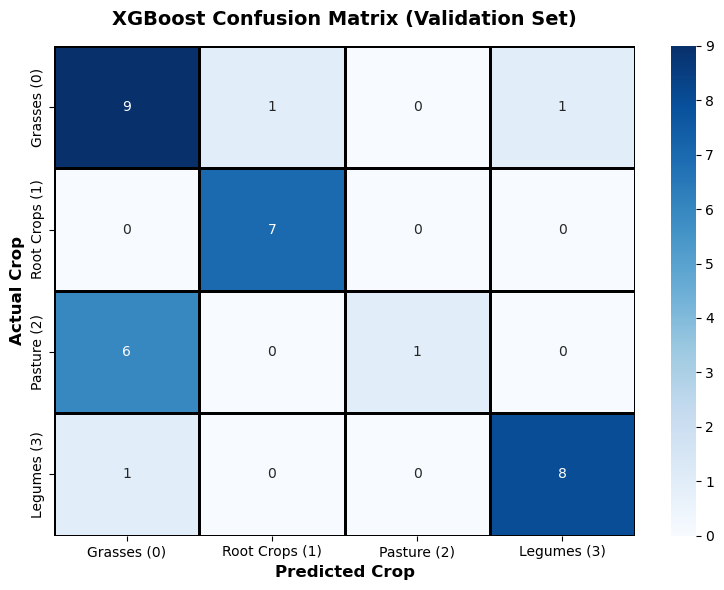


🚨 PART 2: OVERFITTING 'LIE DETECTOR' TEST (5-Fold CV)
Fold 5 -> Train Acc: 0.950 | Val Acc: 0.857 | Gap: 0.093
Fold 6 -> Train Acc: 0.967 | Val Acc: 0.857 | Gap: 0.110
Fold 7 -> Train Acc: 0.950 | Val Acc: 1.000 | Gap: -0.050
Fold 8 -> Train Acc: 0.950 | Val Acc: 0.857 | Gap: 0.093
Fold 9 -> Train Acc: 0.950 | Val Acc: 1.000 | Gap: -0.050
Fold 10 -> Train Acc: 0.950 | Val Acc: 1.000 | Gap: -0.050
Fold 11 -> Train Acc: 0.967 | Val Acc: 0.714 | Gap: 0.252
Fold 12 -> Train Acc: 0.951 | Val Acc: 1.000 | Gap: -0.049
Fold 13 -> Train Acc: 0.951 | Val Acc: 1.000 | Gap: -0.049
Fold 14 -> Train Acc: 0.967 | Val Acc: 0.333 | Gap: 0.634
--------------------------------------------------
📊 FINAL CV AVERAGES:
Average Train Accuracy: 0.955 (95.5%)
Average Val Accuracy:   0.862 (86.2%)
OVERFITTING GAP:        0.093 (9.3%)

🟢 VERDICT: Model is EXCELLENT. It is learning the biology, not memorizing.


In [65]:
import warnings
# 1. REMOVE ALL WARNINGS
warnings.filterwarnings('ignore')
import logging
logging.getLogger("xgboost").setLevel(logging.ERROR)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from xgboost import XGBClassifier

# ==========================================
# 2. LOAD DATA & PREPARE FEATURES
# ==========================================
taxa_path = '/Users/pawanpahune/AI_Pipeline_Metagenomics/merging_pipeline/Filtered_Taxa.csv'
meta_path = '/Users/pawanpahune/AI_Pipeline_Metagenomics/Metadata-without-taxa-v1.csv'

df_taxa = pd.read_csv(taxa_path)
df_meta = pd.read_csv(meta_path)

df_merged = pd.merge(df_taxa, df_meta, on='Code', how='inner')
y = df_merged['Target_Crop_Grouped'].astype(int).values.ravel()

taxa_cols = [col for col in df_taxa.columns if col != 'Code']
meta_cols = [col for col in df_meta.columns if col not in ['Code', 'Target_Crop_Grouped']]

X_taxa_raw = df_merged[taxa_cols]
X_meta = df_merged[meta_cols]

# Apply "Half-Min" CLR to Taxa ONLY
min_non_zero = X_taxa_raw[X_taxa_raw > 0].min().min()
X_taxa_pseudo = X_taxa_raw + (min_non_zero / 2.0)
geom_mean = np.exp(np.mean(np.log(X_taxa_pseudo), axis=1))
X_taxa_clr = np.log(X_taxa_pseudo.div(geom_mean, axis=0))

X_combined = pd.concat([X_meta, X_taxa_clr], axis=1)

# ==========================================
# 3. EXPLICIT, NON-VAGUE XGBOOST PARAMETERS
# ==========================================
xgb_params = {
    'max_depth': 1,                 # EXTREME: "Decision Stumps" (Only 1 split allowed per tree)
    'min_child_weight': 3,          # EXTREME: A rule must apply to at least 10 farms to be valid
    'learning_rate': 0.01,          
    'n_estimators': 100,            
    'colsample_bytree': 0.3,        # EXTREME: Model is blindfolded to 70% of features per tree
    'subsample': 0.8,               
    'reg_alpha': 2.0,               # STRICT: L1 Lasso (Forces weak microbes to exactly 0 weight)
    'reg_lambda': 15.0,             # EXTREME: L2 Ridge (Violently punishes reliance on a single microbe)
    'eval_metric': 'mlogloss',      
    'random_state': 42              
}

xgb_model = XGBClassifier(**xgb_params)

# ==========================================
# 4. TRAIN/VAL SPLIT & DETAILED METRICS
# ==========================================
print("\n" + "="*50)
print("🎯 PART 1: MAIN MODEL EVALUATION")
print("="*50)

X_train, X_val, y_train, y_val = train_test_split(X_combined, y, test_size=0.5, random_state=42, stratify=y)

xgb_model.fit(X_train, y_train)

# Make Predictions
y_pred_train = xgb_model.predict(X_train)
y_pred_val = xgb_model.predict(X_val)

print("--- STANDARD METRICS ---")
print(f"✅ Training Accuracy:   {accuracy_score(y_train, y_pred_train):.3f} ({(accuracy_score(y_train, y_pred_train)*100):.1f}%)")
print(f"✅ Validation Accuracy: {accuracy_score(y_val, y_pred_val):.3f} ({(accuracy_score(y_val, y_pred_val)*100):.1f}%)")
print("")
print(f"✅ Training F1-Score:   {f1_score(y_train, y_pred_train, average='weighted'):.3f}")
print(f"✅ Validation F1-Score: {f1_score(y_val, y_pred_val, average='weighted'):.3f}")
print(f"✅ Validation Balanced Accuracy: {balanced_accuracy_score(y_val, y_pred_val):.3f}")

# ==========================================
# 5. CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(y_val, y_pred_val)

class_names = ['Grasses (0)', 'Root Crops (1)', 'Pasture (2)', 'Legumes (3)']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor='black')
plt.title("XGBoost Confusion Matrix (Validation Set)", fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual Crop', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Crop', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# 6. OVERFITTING CHECK (5-FOLD CROSS VALIDATION)
# ==========================================
print("\n" + "="*50)
print("🚨 PART 2: OVERFITTING 'LIE DETECTOR' TEST (5-Fold CV)")
print("="*50)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

fold = 5
train_acc_scores = []
val_acc_scores = []

for train_index, val_index in skf.split(X_combined, y):
    X_tr_fold, X_v_fold = X_combined.iloc[train_index], X_combined.iloc[val_index]
    y_tr_fold, y_v_fold = y[train_index], y[val_index]
    
    xgb_model.fit(X_tr_fold, y_tr_fold)
    
    train_acc = accuracy_score(y_tr_fold, xgb_model.predict(X_tr_fold))
    val_acc = accuracy_score(y_v_fold, xgb_model.predict(X_v_fold))
    
    train_acc_scores.append(train_acc)
    val_acc_scores.append(val_acc)
    
    print(f"Fold {fold} -> Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f} | Gap: {(train_acc - val_acc):.3f}")
    fold += 1

print("-" * 50)
avg_train_acc = np.mean(train_acc_scores)
avg_val_acc = np.mean(val_acc_scores)

print(f"📊 FINAL CV AVERAGES:")
print(f"Average Train Accuracy: {avg_train_acc:.3f} ({(avg_train_acc*100):.1f}%)")
print(f"Average Val Accuracy:   {avg_val_acc:.3f} ({(avg_val_acc*100):.1f}%)")
print(f"OVERFITTING GAP:        {(avg_train_acc - avg_val_acc):.3f} ({(avg_train_acc - avg_val_acc)*100:.1f}%)")

if (avg_train_acc - avg_val_acc) < 0.15:
    print("\n🟢 VERDICT: Model is EXCELLENT. It is learning the biology, not memorizing.")
elif (avg_train_acc - avg_val_acc) >= 0.15 and (avg_train_acc - avg_val_acc) < 0.25:
    print("\n🟡 VERDICT: Model is acceptable, but slightly overfitting.")
else:
    print("\n🔴 VERDICT: Model is OVERFITTING. The gap is too large.")
print("="*50)

## TRY 3 

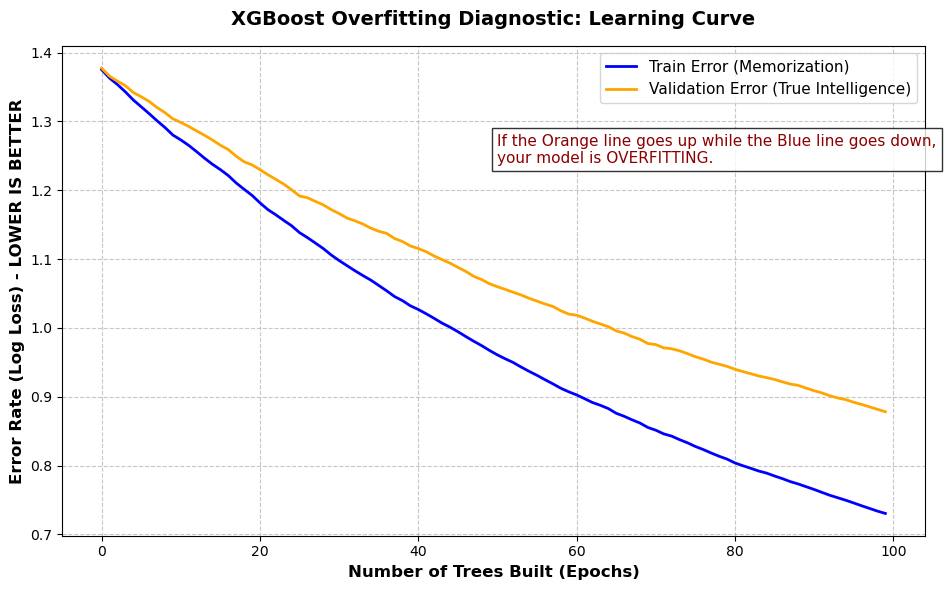

📉 Final Train Error: 0.7303
📉 Final Val Error:   0.8781
⚠️ Error Gap:         0.1478

🟢 VERDICT: HEALTHY MODEL. The model is genuinely learning!


In [63]:
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger("xgboost").setLevel(logging.ERROR)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# ==========================================
# 1. LOAD DATA & PREPARE COMBINED FEATURES
# ==========================================
taxa_path = '/Users/pawanpahune/AI_Pipeline_Metagenomics/merging_pipeline/Filtered_Taxa.csv'
meta_path = '/Users/pawanpahune/AI_Pipeline_Metagenomics/Metadata-without-taxa-v1.csv'

df_taxa = pd.read_csv(taxa_path)
df_meta = pd.read_csv(meta_path)

df_merged = pd.merge(df_taxa, df_meta, on='Code', how='inner')
y = df_merged['Target_Crop_Grouped'].astype(int).values.ravel()

taxa_cols = [col for col in df_taxa.columns if col != 'Code']
meta_cols = [col for col in df_meta.columns if col not in ['Code', 'Target_Crop_Grouped']]

X_taxa_raw = df_merged[taxa_cols]
X_meta = df_merged[meta_cols]

# Apply "Half-Min" CLR to Taxa ONLY
min_non_zero = X_taxa_raw[X_taxa_raw > 0].min().min()
X_taxa_pseudo = X_taxa_raw + (min_non_zero / 2.0)
geom_mean = np.exp(np.mean(np.log(X_taxa_pseudo), axis=1))
X_taxa_clr = np.log(X_taxa_pseudo.div(geom_mean, axis=0))

X_combined = pd.concat([X_meta, X_taxa_clr], axis=1)

# Split the data
X_train, X_val, y_train, y_val = train_test_split(X_combined, y, test_size=0.30, random_state=42, stratify=y)

# ==========================================
# 2. TRAIN XGBOOST & RECORD EVALUATION
# ==========================================
xgb_params = {
    'max_depth': 2,                 # EXTREME: "Decision Stumps" (Only 1 split allowed per tree)
    'min_child_weight': 1,          # EXTREME: A rule must apply to at least 10 farms to be valid
    'learning_rate': 0.05,          
    'n_estimators': 100,            
    'colsample_bytree': 0.3,        # EXTREME: Model is blindfolded to 70% of features per tree
    'subsample': 0.8,               
    'reg_alpha': 2.0,               # STRICT: L1 Lasso (Forces weak microbes to exactly 0 weight)
    'reg_lambda': 15.0,             # EXTREME: L2 Ridge (Violently punishes reliance on a single microbe)
    'eval_metric': 'mlogloss',      
    'random_state': 42              
}

xgb_model = XGBClassifier(**xgb_params)

# We pass BOTH the Train and Validation sets into the 'eval_set' 
# so XGBoost tracks its performance on both after every single tree is built.
eval_set = [(X_train, y_train), (X_val, y_val)]

xgb_model.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=False
)

# Retrieve the recorded errors
results = xgb_model.evals_result()
epochs = len(results['validation_0']['mlogloss'])
x_axis = range(0, epochs)

# ==========================================
# 3. PLOT THE LEARNING CURVE
# ==========================================
plt.figure(figsize=(10, 6))

# Plot Training Error (Blue)
plt.plot(x_axis, results['validation_0']['mlogloss'], label='Train Error (Memorization)', color='blue', linewidth=2)

# Plot Validation Error (Orange)
plt.plot(x_axis, results['validation_1']['mlogloss'], label='Validation Error (True Intelligence)', color='orange', linewidth=2)

plt.title('XGBoost Overfitting Diagnostic: Learning Curve', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Trees Built (Epochs)', fontsize=12, fontweight='bold')
plt.ylabel('Error Rate (Log Loss) - LOWER IS BETTER', fontsize=12, fontweight='bold')
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# Add interpretation text to the chart
plt.text(epochs*0.5, max(results['validation_1']['mlogloss'])*0.9, 
         "If the Orange line goes up while the Blue line goes down,\nyour model is OVERFITTING.", 
         fontsize=11, color='darkred', bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# ==========================================
# 4. PRINT THE FINAL GAP
# ==========================================
final_train_error = results['validation_0']['mlogloss'][-1]
final_val_error = results['validation_1']['mlogloss'][-1]
gap = final_val_error - final_train_error

print(f"📉 Final Train Error: {final_train_error:.4f}")
print(f"📉 Final Val Error:   {final_val_error:.4f}")
print(f"⚠️ Error Gap:         {gap:.4f}")

if gap > 0.5:
    print("\n🔴 VERDICT: SEVERE OVERFITTING. The model memorized the data.")
elif gap > 0.2:
    print("\n🟡 VERDICT: MODERATE OVERFITTING. The regularizations are helping, but the data is very small.")
else:
    print("\n🟢 VERDICT: HEALTHY MODEL. The model is genuinely learning!")